**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [370]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [371]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

Si comparem el gràfic de l’entrada x[n] amb el de la sortida y[n] podem veure que les transicions entre nivells són més lentes i menys pronunciades. Els angles d'atac es redueixen i l'output presenta una forma més contínua ja que és la mitjana de la mostra actual i de les quatre anteriors. Aquest filtre elimina part del soroll d’alta freqüència i manté només les variacions lentes del senyal original.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [372]:
import numpy as np

def averaging_filter(x, N, mode='same'):
    """
    Applies a N-point averaging filter to the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the filter
    """  
    b = np.ones(N) / N
    y = np.convolve(b, x, mode=mode)
    
    return y


1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

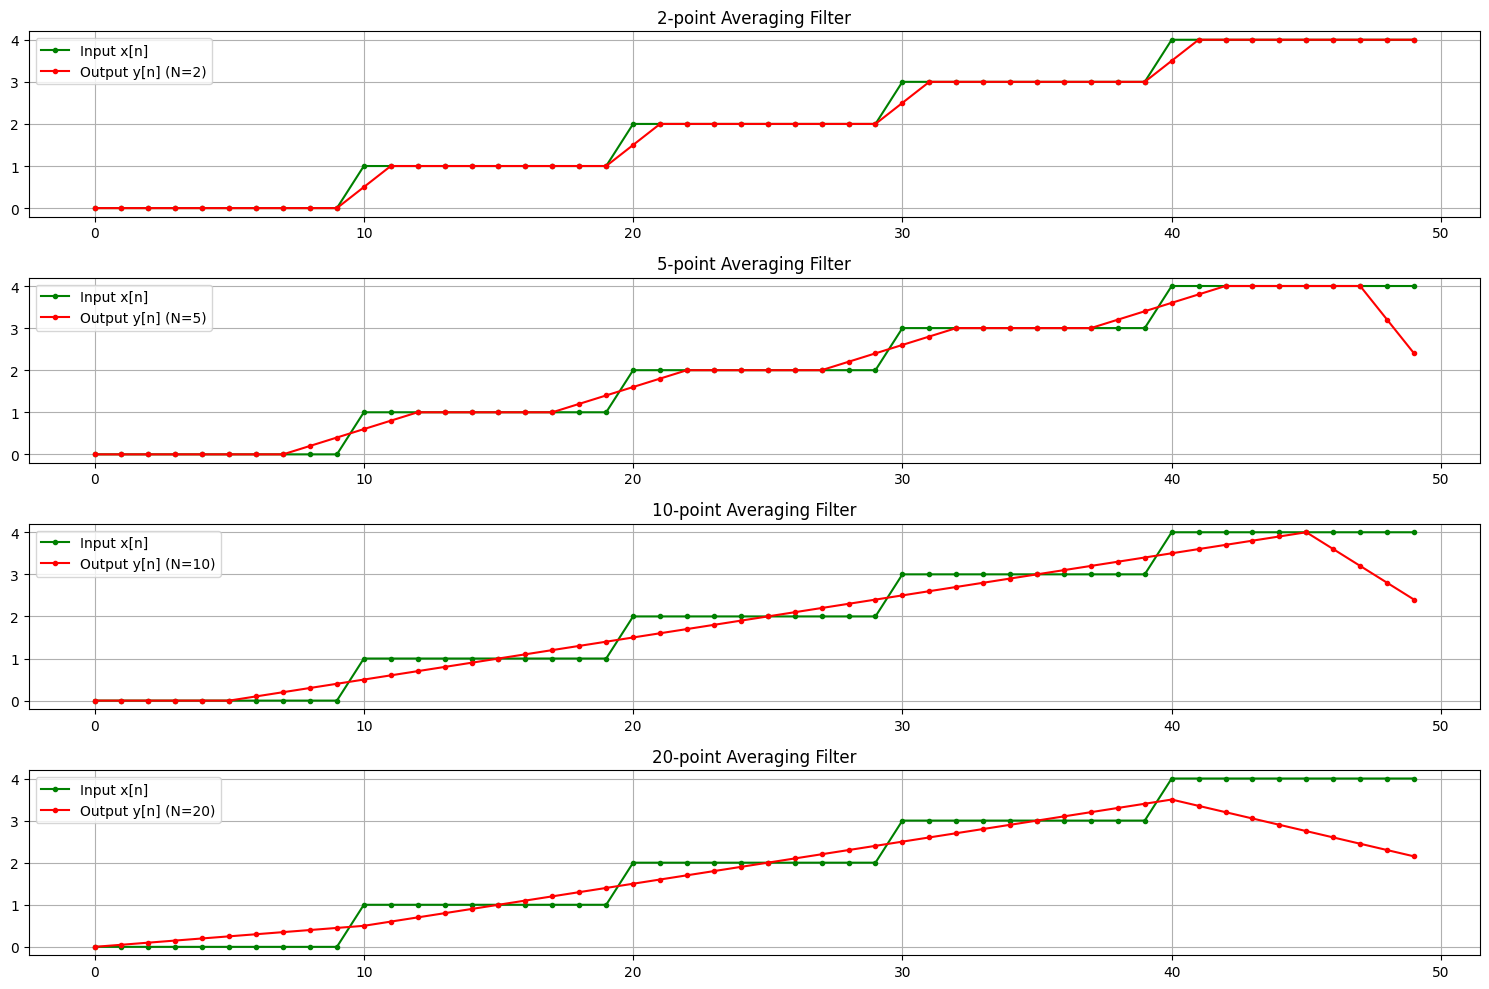

In [373]:
# Provar amb diferents valors de N aleatoris
N_values = [2, 5, 10, 20]

plt.figure(figsize=(15, 10))
for i, N in enumerate(N_values):
    y = averaging_filter(x, N)
    
    plt.subplot(len(N_values), 1, i+1)
    plt.plot(x, 'g.-', label='Input x[n]')
    plt.plot(y, 'r.-', label=f'Output y[n] (N={N})')
    plt.legend()
    plt.title(f'{N}-point Averaging Filter')
    plt.grid(True)

plt.tight_layout()

Quan augmentem els valors de N veiem que el gràfic de l'output queda més suavitzat i les transicions són més lentes i suaus. Quan la N és 20 és gairebé una recta i és més contínua que quan N és menor (per exemple 2). Quan augmentem N es veu que es perd detall del senyal original.

1.4 How would you classify this filter, as a low-pass o high-pass filter?

El filtre es classifica com a low-pass, ja que al fer la mitjana de diverses mostres redueix o elimina les components d'alta freqüència i es mantenen les components de baixa freqüència. Així suavitza el senyal i es produeix una sortida més estable i sense soroll.

---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

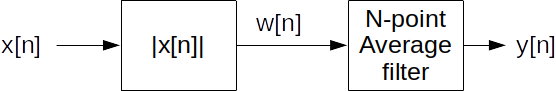

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [374]:
def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    w = np.abs(x)
    y = averaging_filter(w, N)
    
    return y


2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

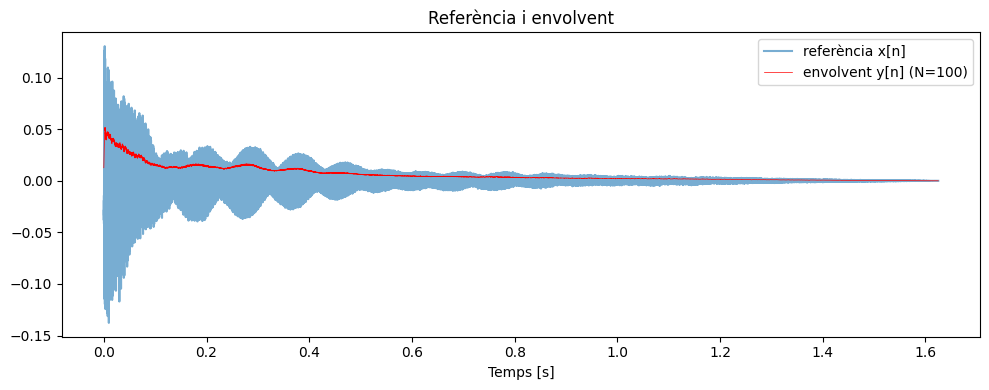

In [375]:
filepath = "./audio/Guitar-string-plucked-at-headstock.wav"
ref, fs = load_audio(filepath)
ipd.Audio(ref, rate=fs)
N = 100
env_ref = envelope(ref, N)

t = np.arange(len(ref)) / fs
plt.figure(figsize=(10,4))
plt.plot(t, ref, label='referència x[n]', alpha=0.6)
plt.plot(t, env_ref, 'r', label=f'envolvent y[n] (N={N})', linewidth=0.5)
plt.xlabel('Temps [s]')
plt.legend()
plt.title('Referència i envolvent')
plt.tight_layout()
plt.show()

2.3 Change the number N to get a good result. What happens when you change the number N?

Quan canviem el valor de N, estem canviant la mida de la finestra de mitjana del filtre i per tant, el nivell de suavitat de l'envolvent. Quan N és més petit (per exemple 5 o 15) l'envolvent segueix molt de prop les oscil·lacions del senyal original. Quan N és més gran (per exemple 100 o 200) l'envolvent és més suau i estable però l'atac inicial queda retardat 

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

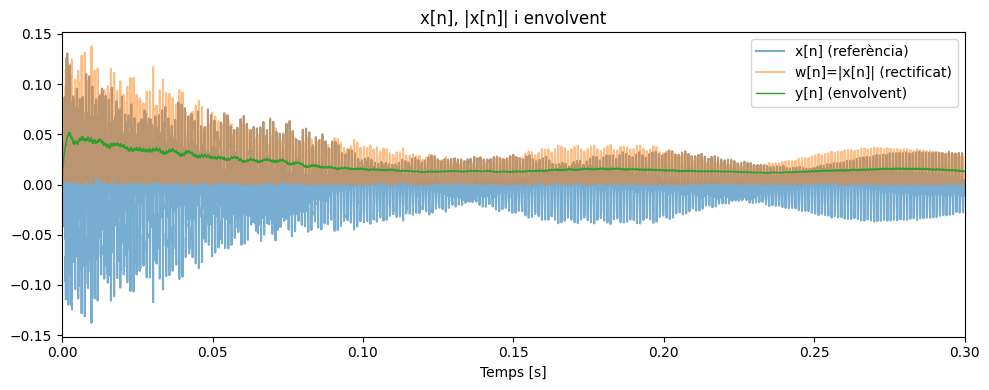

In [376]:
w = np.abs(ref)
y = env_ref
t = np.arange(len(ref))/fs
plt.figure(figsize=(10,4))
plt.plot(t, ref, label='x[n] (referència)', alpha=0.6)
plt.plot(t, w, label='w[n]=|x[n]| (rectificat)', alpha=0.5)
plt.plot(t, y, label='y[n] (envolvent)', linewidth=1)
plt.xlim(0, 0.3)   # mostra només el primer segment per veure detalls
plt.legend()
plt.xlabel('Temps [s]')
plt.title('x[n], |x[n]| i envolvent')
plt.tight_layout()
plt.show()


Primer rectifiquem i convertim totes les mostres a valors positius. Després de rectificar el senyal, encara té fluctuacions ràpides, apliquem un filtre que suavitza les variacions i actua com a low-pass, eliminant les oscil·lacions ràpides i deixant només els canvis lents d'amplitud,és a dir, l'envolvent del senyal.

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [377]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

weights = [1, 0.5594, 0.07859, 0.06199, 0.1524, 0.04914, 0.04642, 0.02122, 0.008588, 0.01908]


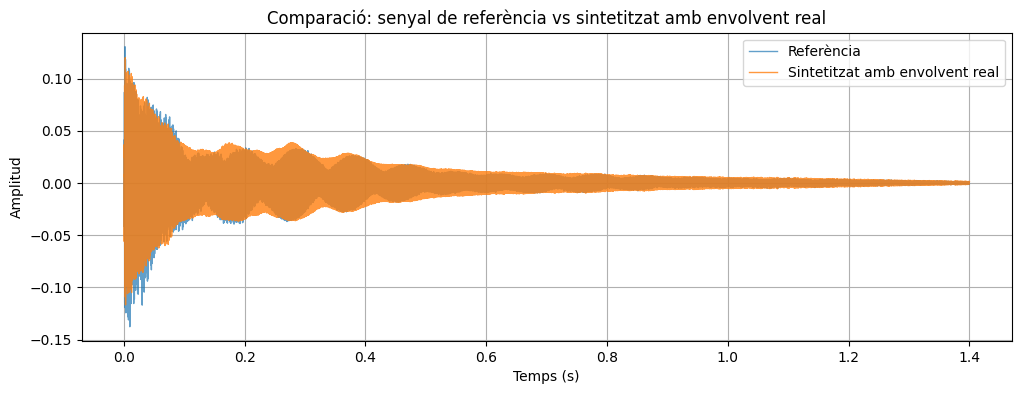

In [378]:
f0 = 904.39  #freq fonamental
phi = 0
A_ref = 0.12  # amplitud de referència

# Vector de temps amb la mateixa longitud que el senyal de referència
t = np.arange(len(ref)) / fs

Ak = np.array(weights)  
y_synt = synthesize(f0, phi, Ak, t)

y_synt_env = y_synt * env_ref

# Normalitza per tenir la mateixa amplitud màxima que la referència
if np.max(np.abs(y_synt_env)) > 0:
    y_synt_env = A_ref * y_synt_env / np.max(np.abs(y_synt_env))

# Mostrem una part del senyal per comparar
duration = 1.4
samples = int(duration * fs)

plt.figure(figsize=(12, 4))
plt.plot(t[:samples], ref[:samples], label='Referència', alpha=0.7, linewidth=1)
plt.plot(t[:samples], y_synt_env[:samples], label='Sintetitzat amb envolvent real', alpha=0.8, linewidth=1)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.title("Comparació: senyal de referència vs sintetitzat amb envolvent real")
plt.show()


2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

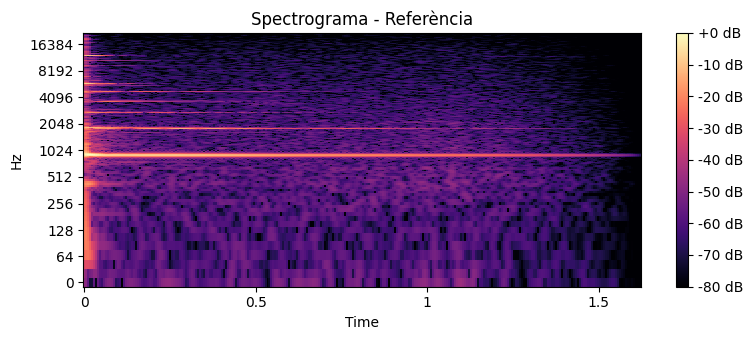

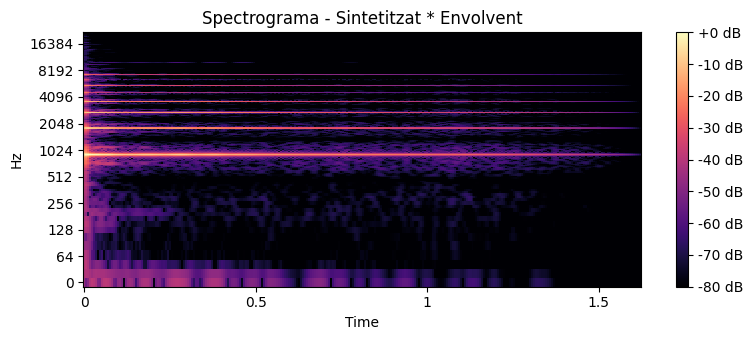

In [379]:
def plot_spectrogram(x, sr, title):
    D = np.abs(librosa.stft(x, n_fft=2048, hop_length=256))
    plt.figure(figsize=(8,3.5))
    librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max),
                             sr=sr, hop_length=256, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spectrogram(ref, fs, 'Spectrograma - Referència')
plot_spectrogram(synth_shaped, fs, 'Spectrograma - Sintetitzat * Envolvent')

Els dos spectrogrames són força similars, els patrons harmònics són gairebé idèntics amb línies horitzontals bastant definides i paral·leles en el sintetitzat. El senyal de referència té més soroll i textures per tant sona més pur o natural que el sintetitzat. El timbre del de referència és ric i complex mentre que el del sintetitzat segueix sonant una mica artificial.

2.7 Listen to the synthesized signal and compare it to the reference.



In [380]:
print("Referència:")
display(ipd.Audio(ref, rate=fs))

Referència:


In [381]:
print("Sintetitzat:")
display(ipd.Audio(y_synt_env, rate=fs))

Sintetitzat:
